<a href="https://colab.research.google.com/github/AlissonValencia/IA_practicas/blob/main/ia_practica3_Valencia_Larrea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

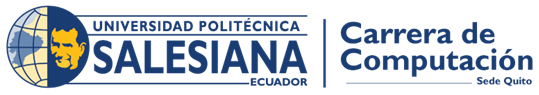

## **El Perceptrón**

Nombre: Alisson Valencia

Materia: Inteligencia Artificial

Práctica: 3

---

***ACTIVIDADES A DESARROLLAR:***


Antes de implementar un modelo neuronal, es necesario comprender que el perceptrón no es una “red
neuronal”, sino una unidad de decisión lineal. Su objetivo es encontrar una frontera que separe dos clases
mediante una combinación ponderada de entradas.

En esta práctica trabajarás con un conjunto de puntos bidimensionales etiquetados con dos clases: -1 y 1.
Tu tarea será implementar un perceptrón capaz de aprender una frontera de decisión para separar ambas
clases.

#**Fase 1. Exploración del Dataset**

El perceptrón trabaja con datos numéricos. En este caso, cada instancia tiene dos variables de entrada: X1,
X2 y una etiqueta de salida: y ∈ { −1, 1 }

**1.1 Carga del Dataset**

Crear una matriz denominada X y un vector y con los siguientes datos:

In [1]:
import pandas as pd

# Datos
datos = {
    "x1": [1, 1, 3, 4, 4, 6, 6, 6, 7, 9, 9, 11, 12, 16,
           4, 6, 8, 9, 10, 12, 12, 14, 16],

    "x2": [7, 3, 4, 6, 2, 6, 2, 0, 4, 3, 1, 1, 3, 2,
           8, 8, 9, 7, 11, 9, 6, 7, 4],

    "Clase (y)":  [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
           -1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}

# Crear DataFrame
tabla = pd.DataFrame(datos)

# Mostrar tabla con diseño y sin índice
print("\nTABLA DE DATOS\n")

print(
    tabla.to_string(
        index=False,
        col_space=10
    )
)

# Crear matriz X y vector y
X = tabla[["x1", "x2"]].values
y = tabla["Clase (y)"].values

print("\nMatriz X:")
print(X)

print("\nVector y:")
print(y)


TABLA DE DATOS

        x1         x2  Clase (y)
         1          7         -1
         1          3         -1
         3          4         -1
         4          6         -1
         4          2         -1
         6          6         -1
         6          2         -1
         6          0         -1
         7          4         -1
         9          3         -1
         9          1         -1
        11          1         -1
        12          3         -1
        16          2         -1
         4          8          1
         6          8          1
         8          9          1
         9          7          1
        10         11          1
        12          9          1
        12          6          1
        14          7          1
        16          4          1

Matriz X:
[[ 1  7]
 [ 1  3]
 [ 3  4]
 [ 4  6]
 [ 4  2]
 [ 6  6]
 [ 6  2]
 [ 6  0]
 [ 7  4]
 [ 9  3]
 [ 9  1]
 [11  1]
 [12  3]
 [16  2]
 [ 4  8]
 [ 6  8]
 [ 8  9]
 [ 9  7]
 [10 11]
 [12  9]


**Actividad 1.a — Inspección inicial**

Identifica los siguientes datos:


In [2]:
# Número total de instancias
total_instancias = len(X)

# Variables de entrada
variables_entrada = len(X[0])

# Número de clases
clases = set(y)

# Conteo por clase
negativos = 0
positivos = 0

for clase in y:

    if clase == -1:
        negativos += 1

    elif clase == 1:
        positivos += 1

# Mostrar resultados
print("Número total de instancias:", total_instancias)
print("Variables de entrada:", variables_entrada)
print("Número de clases:", len(clases))
print("Cantidad clase -1:", negativos)
print("Cantidad clase +1:", positivos)

Número total de instancias: 23
Variables de entrada: 2
Número de clases: 2
Cantidad clase -1: 14
Cantidad clase +1: 9


*   Pregunta guía: ¿Qué representa cada fila de X? ¿Qué representa cada valor del vector y? ¿Por qué este problema se considera de clasificación binaria?

        Cada fila de X representa una instancia o punto del dataset con dos características:
          - x1
          - x2
        Cada valor del vector y representa la clase a la que pertenece cada punto:
          - -1
          - +1
        Este problema se considera de clasificación binaria porque únicamente existen dos posibles clases de salida.



**Actividad 1.b — Separación visual de las clases**

Crea una función que permita grafica los puntos en un plano cartesiano. Utiliza un marcador diferente para
la clase -1 y para la clase 1. Puedes utilizar matplotlib para esta actividad. La gráfica debería mirarse
similar a la siguiente figura.

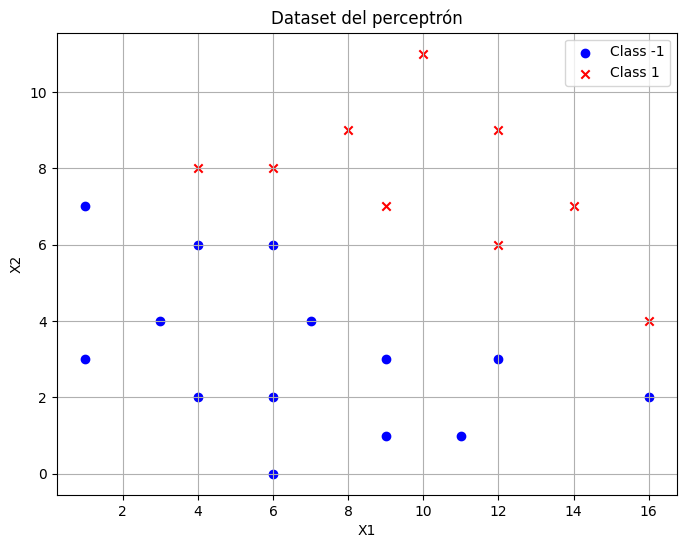

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_data(X, y):
    X_class_neg1 = X[y == -1]
    X_class_pos1 = X[y == 1]

    plt.figure(figsize=(8, 6))
    plt.scatter(X_class_neg1[:, 0], X_class_neg1[:, 1], marker='o', color='blue', label='Class -1')
    plt.scatter(X_class_pos1[:, 0], X_class_pos1[:, 1], marker='x', color='red', label='Class 1')

    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Dataset del perceptrón')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_data(X, y)

*   Pregunta guía: Observando únicamente la gráfica, ¿parece posible separar las dos clases mediante una sola recta? Justifica tu respuesta.

        Sí parece posible separar ambas clases mediante una sola recta porque los puntos positivos y negativos forman grupos relativamente diferenciados en el plano cartesiano.
        Esto indica que el dataset es linealmente separable.



#**Fase 2. Fundamento del Perceptrón**

El perceptrón es un clasificador lineal supervisado. Recibe entradas numéricas, calcula una suma
ponderada, aplica una función de activación y produce una salida binaria.

Para una instancia con dos entradas:

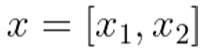

El perceptrón calcula:
        
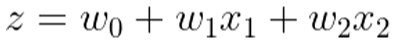

Donde:
* w0 es el bias o sesgo
* w1 es el peso asociado a x1
* w2 es el peso asociado a x

La salida se obtiene aplicando la función escalón bipolar:

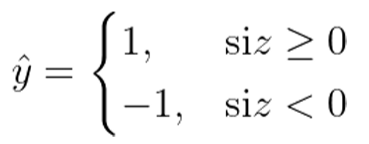

La frontera de decisión está definida por:

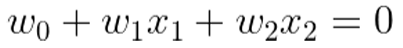

***2.1 Actividades sobre el modelo***

**Actividad 2.a — Vector de pesos**


Crea una función llamada initialize_weights() que retorne tres pesos aleatorios pequeños. Los
pesos deben generarse en un rango pequeño, por ejemplo entre -0.5 y 0.5.


In [4]:
import random

def initialize_weights():

    w0 = random.uniform(-0.5, 0.5)
    w1 = random.uniform(-0.5, 0.5)
    w2 = random.uniform(-0.5, 0.5)

    return [w0, w1, w2]

w = initialize_weights()

print("Pesos iniciales:")
print(w)

Pesos iniciales:
[-0.3282134562524718, 0.25951247631907615, 0.38859787066885787]


*   Pregunta guía: ¿Por qué el vector de pesos tiene tres valores si cada instancia de entrada solo tiene dos variables? ¿Qué función cumple el bias en el modelo?

        - El vector de pesos tiene tres valores porque además de los pesos asociados a x1 y x2, también existe un bias o sesgo.
        - El bias permite desplazar la frontera de decisión en el plano cartesiano y evita que la recta pase obligatoriamente por
          el origen.



**Actividad 2.b — Función de activación**

Crea una función llamada activation(z) que reciba el valor de la suma ponderada y retorne el
resultado de la función escalón bipolar:


In [5]:
def activation(z):

    if z >= 0:
        return 1

    else:
        return -1

*   Pregunta guía: ¿Por qué en esta práctica se utilizan las etiquetas -1 y 1 en lugar de 0 y 1? ¿Qué ventaja tiene esta representación para el algoritmo del perceptrón?

        - Se utilizan etiquetas -1 y 1 porque facilitan la regla de actualización de pesos del perceptrón.
        - Esta representación permite manejar los errores de clasificación de manera más simétrica y simplifica
          los cálculos matemáticos.




**Actividad 2.c — Cálculo de salida**

Crea una función llamada perceptron_compute(x, w). La función debe recibir una sola instancia x =
[x1, x2] y el vector de pesos w = [w0, w1, w2]. Esta función debe calcular la suma ponderada z y
retornar la salida producida por la función de activación.

In [6]:
def perceptron_compute(x, w):

    z = (
        w[0] +
        w[1] * x[0] +
        w[2] * x[1]
    )

    salida = activation(z)

    return salida

print(perceptron_compute(X[0], w))
print(perceptron_compute(X[5], w))
print(perceptron_compute(X[15], w))

1
1
1


*   Pregunta guía: ¿Cuál es la diferencia entre la suma ponderada z y la salida final del perceptrón? ¿Por qué no basta con calcular solo z?

        - La suma ponderada z representa el valor numérico calculado por el perceptrón antes de decidir una clase.
        - La salida final corresponde a la aplicación de la función de activación.
        - No basta calcular solo z porque el objetivo del perceptrón es producir una clasificación binaria.



#**Fase 3. Visualización de la Frontera de Decisión**

El perceptrón divide el plano mediante una recta. Para visualizar esa recta, partimos de la ecuación:

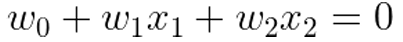

Si despejamos x2:

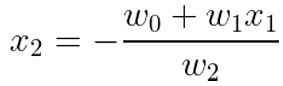

Esta expresión permite graficar la frontera de decisión.

***3.1 Actividades de visualización***

**Actividad 3.a — Función de graficación**

Crea una función llamada perceptron_plot(X, y, w, title). La función debe: • Graficar los puntos de la clase -1.

* Graficar los puntos de la clase 1.

* Graficar la frontera de decisión correspondiente al vector de pesos w.

* Colocar título, etiquetas de ejes, leyenda y cuadrícula.

Considera el siguiente caso especial:

* Si w2 ≠ 0, puedes despejar x2

* Si w2 = 0, la recta no puede despejarse de esa forma y debes evitar la división para cero.

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def perceptron_plot(X, y, w, title):

    # Convertir a numpy arrays
    X = np.array(X)
    y = np.array(y)

    # Separar clases
    X_class_neg1 = X[y == -1]
    X_class_pos1 = X[y == 1]

    # Crear figura
    plt.figure(figsize=(8, 6))

    # Graficar clase -1
    plt.scatter(
        X_class_neg1[:, 0],
        X_class_neg1[:, 1],
        marker='o',
        label='Clase -1'
    )

    # Graficar clase +1
    plt.scatter(
        X_class_pos1[:, 0],
        X_class_pos1[:, 1],
        marker='x',
        label='Clase +1'
    )

    # Frontera de decisión
    # w0 + w1*x1 + w2*x2 = 0

    x1_min = X[:, 0].min() - 1
    x1_max = X[:, 0].max() + 1

    xx1 = np.linspace(x1_min, x1_max, 100)

    # Caso normal: w2 != 0
    if w[2] != 0:

        xx2 = (
            -w[0] - w[1] * xx1
        ) / w[2]

        plt.plot(
            xx1,
            xx2,
            linestyle='--',
            label='Frontera'
        )

    # Caso especial: w2 == 0
    elif w[1] != 0:

        x_vertical = -w[0] / w[1]

        plt.axvline(
            x=x_vertical,
            linestyle='--',
            label='Frontera'
        )

    # Etiquetas
    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.title(title)

    plt.legend()

    plt.grid(True)

    plt.show()

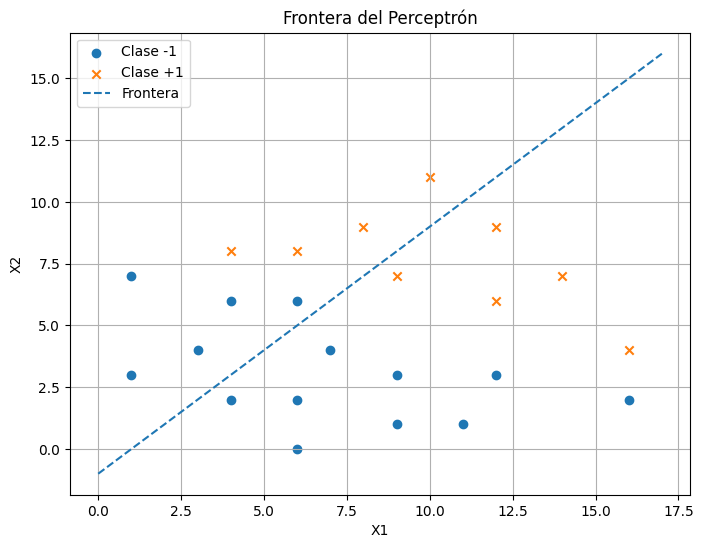

In [8]:
w = [1, -1, 1]

perceptron_plot(
    X,
    y,
    w,
    "Frontera del Perceptrón"
)

*   Pregunta guía: ¿Qué representa geométricamente la recta generada por el perceptrón? ¿Qué ocurre si los pesos iniciales son aleatorios?

        - La recta generada representa la frontera de decisión del perceptrón, esta recta divide el plano en dos regiones
          correspondientes a las clases.
        - Si los pesos son aleatorios, la frontera inicial también será aleatoria y normalmente no clasificará correctamente
          todos los puntos.



**Actividad 3.b — Gráfica con pesos iniciales**

Inicializa pesos aleatorios pequeños y grafica la frontera inicial.

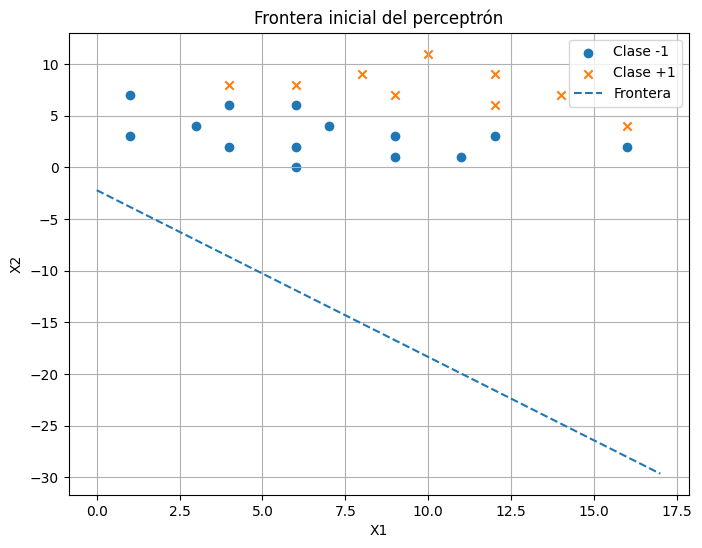

In [9]:
w_initial = initialize_weights()
perceptron_plot(X, y, w_initial, "Frontera inicial del perceptrón")

*   Pregunta guía: ¿La frontera inicial clasifica correctamente los puntos? ¿Por qué no deberíamos esperar que una frontera con pesos aleatorios sea correcta?

        - La frontera inicial normalmente no clasifica correctamente los puntos porque los pesos todavía no han sido entrenados.
        - No debemos esperar una clasificación correcta con pesos aleatorios ya que el modelo aún no ha aprendido la separación entre clases.



#**Fase 4. Entrenamiento del Perceptrón**

El perceptrón aprende modificando sus pesos cuando comete errores. Para cada instancia de entrenamiento, se calcula una predicción. Si la predicción es incorrecta, los pesos se actualizan.

La regla de actualización es:

        Wi <- Wi + η(y - ŷ )Xi

Para el bias:

        W0 <- W0 + η(y - ŷ )

Donde:

* η es la tasa de aprendizaje

* y es la etiqueta real

* ŷ es la etiqueta predicha

* xi es la entrada correspondiente

***4.1 Actividades de entrenamiento***

**Actividad 4.a — Implementación de la función de aprendizaje**

Crea una función llamada perceptron_learning(X, y, w, lr, max_epochs). La función debe recibir:

* Matriz de datos X

* Vector de etiquetas y

* Pesos iniciales w

* tasa de aprendizaje lr

* Número máximo de épocas max_epochs.

La función debe retornar:

* Pesos finales

* Número de épocas realizadas

* Número total de actualizaciones

* Lista con la evolución de pesos W_values;

* Lista con la evolución del error E_values.

La función debe entrenar hasta que:

* No exista ningún error de clasificación en una época o

* Se alcance el número máximo de épocas.

In [10]:
def perceptron_learning(
    X,
    y,
    w,
    lr,
    max_epochs
):

    # Guardar evolución de pesos
    W_values = []

    # Guardar evolución del error
    E_values = []

    # Contador total de actualizaciones
    updates = 0

    # entrenamiento
    for epoch in range(max_epochs):

        errors = 0

        # Recorrer dataset
        for i in range(len(X)):

            # Predicción
            y_pred = perceptron_compute(
                X[i],
                w
            )

            # Si existe error
            if y_pred != y[i]:

                # Actualizar bias
                w[0] = (
                    w[0] +
                    lr * y[i]
                )

                # Actualizar peso x1
                w[1] = (
                    w[1] +
                    lr * y[i] * X[i][0]
                )

                # Actualizar peso x2
                w[2] = (
                    w[2] +
                    lr * y[i] * X[i][1]
                )

                # Contadores
                updates += 1
                errors += 1

        # error de la epoca
        error_rate = errors / len(X)

        E_values.append(error_rate)

        # Guardar copia de pesos
        W_values.append(w.copy())

        # criterio de parada
        if errors == 0:

            print("Convergencia alcanzada.")

            return (
                w,
                epoch + 1,
                updates,
                W_values,
                E_values
            )

    # sino converge
    print("Se alcanzó el máximo de épocas.")

    return (
        w,
        max_epochs,
        updates,
        W_values,
        E_values
    )

In [11]:
# Pesos iniciales
w = initialize_weights()

# Entrenar
final_w, epochs, updates, W_values, E_values = perceptron_learning(
    X,
    y,
    w,
    lr=0.5,
    max_epochs=1000
)

print("\nPesos finales:")
print(final_w)

print("\nÉpocas:")
print(epochs)

print("\nActualizaciones:")
print(updates)

print("\nErrores por época:")
print(E_values)

Convergencia alcanzada.

Pesos finales:
[np.float64(-14.16353155566042), np.float64(0.5129129188831705), np.float64(1.8458127534871291)]

Épocas:
35

Actualizaciones:
115

Errores por época:
[0.043478260869565216, 0.21739130434782608, 0.2608695652173913, 0.08695652173913043, 0.13043478260869565, 0.13043478260869565, 0.08695652173913043, 0.13043478260869565, 0.08695652173913043, 0.13043478260869565, 0.08695652173913043, 0.13043478260869565, 0.08695652173913043, 0.17391304347826086, 0.30434782608695654, 0.2608695652173913, 0.17391304347826086, 0.08695652173913043, 0.13043478260869565, 0.08695652173913043, 0.13043478260869565, 0.08695652173913043, 0.17391304347826086, 0.2608695652173913, 0.17391304347826086, 0.08695652173913043, 0.17391304347826086, 0.21739130434782608, 0.2608695652173913, 0.17391304347826086, 0.08695652173913043, 0.17391304347826086, 0.13043478260869565, 0.043478260869565216, 0.0]


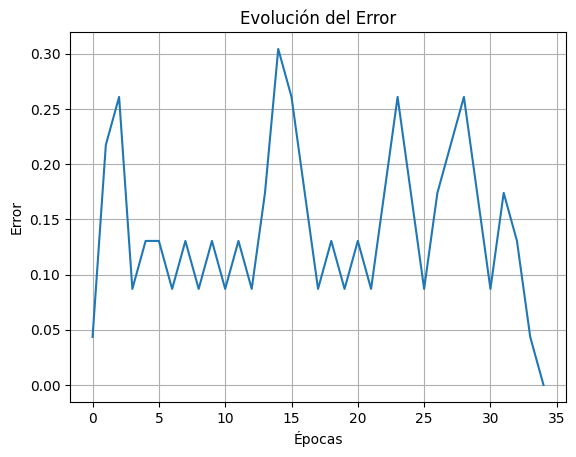

In [12]:
plt.plot(E_values)

plt.xlabel("Épocas")
plt.ylabel("Error")

plt.title("Evolución del Error")

plt.grid(True)

plt.show()

*   Pregunta guía: ¿Por qué es necesario incluir un número máximo de épocas? ¿Qué podría ocurrir si el dataset no fuera linealmente separable?

        - Es necesario incluir un número máximo de épocas para evitar ciclos infinitos durante el entrenamiento.
        - Si el dataset no fuera linealmente separable, el perceptrón nunca lograría clasificar correctamente todos
          los puntos y el algoritmo continuaría actualizando pesos indefinidamente.

**Actividad 4.b — Registro del error**

Durante cada época, calcula la tasa de error:

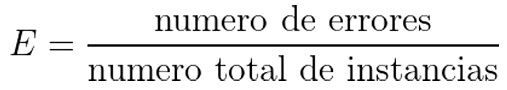

Guarda ese valor en la lista E_values.

*   Pregunta guía: ¿Qué significa que la tasa de error llegue a cero?

        Que la tasa de error llegue a cero significa que todas las instancias fueron clasificadas correctamente
        durante una época completa.



**Actividad 4.c — Registro de pesos**

Después de cada época, guarda una copia del vector de pesos en W_values. Importante: no guardes la misma referencia del objeto w; guarda una copia de sus valores.


*   Pregunta guía: ¿Por qué es importante guardar copias de los pesos y no solo el vector w? ¿Qué problema aparecería al intentar graficar la evolución del entrenamiento?

        - Es importante guardar copias de los pesos porque el vector w cambia continuamente durante el entrenamiento.
        - Si solo se guardara la referencia del objeto, todas las posiciones de la lista terminarían mostrando
          los mismos pesos finales.



#**Fase 5. Entrenamiento con tasa de aprendizaje 0.5**

En esta fase entrenarás el perceptrón con:

        * lr = 0.5
        * max_epochs = 1000

***5.1 Actividades de entrenamiento inicial***

**Actividad 5.a — Entrena el modelo**

Inicializa pesos aleatorios y entrena el perceptrón.

In [13]:
w = initialize_weights()
final_w, epochs, updates, W_values, E_values = perceptron_learning(
    X,
    y,
    w,
    lr=0.5,
    max_epochs=1000
    )

Convergencia alcanzada.


In [14]:
w = initialize_weights()

print("Pesos iniciales:")
print(w)

final_w, epochs, updates, W_values, E_values = perceptron_learning(
    X,
    y,
    w,
    lr=0.5,
    max_epochs=1000
)

print("\nPesos finales:")
print(final_w)

print("\nNúmero de épocas:")
print(epochs)

print("\nActualizaciones:")
print(updates)

print("\nError final:")
print(E_values[-1])

Pesos iniciales:
[0.15501043330684938, 0.4933916705103393, -0.3232799515812337]
Convergencia alcanzada.

Pesos finales:
[np.float64(-34.34498956669315), np.float64(0.9933916705103396), np.float64(4.676720048418765)]

Número de épocas:
121

Actualizaciones:
393

Error final:
0.0


Muestra:

* Pesos iniciales

* Pesos finales

* Número de épocas

* Número total de actualizaciones

* Error final

*   Pregunta guía: ¿El perceptrón logró converger? ¿Cómo puedes comprobarlo usando la lista y la gráfica final?


        Sí, el perceptrón logró converger porque el error final llegó a cero y la frontera final separa correctamente ambas clases.


**Actividad 5.b — Frontera final**

Grafica la frontera de decisión final. perceptron_plot(X, y, final_w, "Frontera final con lr = 0.5")

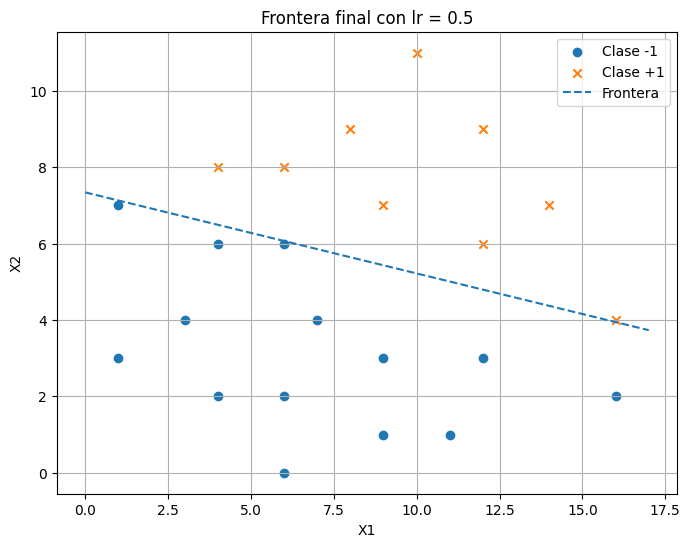

In [15]:
perceptron_plot(
    X,
    y,
    final_w,
    "Frontera final con lr = 0.5"
)

*   Pregunta guía: ¿La frontera final separa correctamente las dos clases? ¿Qué diferencias observas respecto a la frontera inicial?


        - La frontera final separa correctamente las dos clases.
        - A diferencia de la frontera inicial, la recta final se ajusta a la distribución real de los datos.


#**Fase 6. Predicción con Nuevas Instancias**

Una vez entrenado el perceptrón, se utilizará para clasificar nuevas instancias que no fueron usadas durante el entrenamiento. Usa las siguientes instancias:

In [17]:
X_test = [
    [5, 5],
    [10, 6],
    [6, 10]
]
print(f"{'Instancia':<15}Salida")
for instancia in X_test:

    salida = perceptron_compute(
        instancia,
        final_w
    )
    print(f"{str(instancia):<15}{salida}")

Instancia      Salida
[5, 5]         -1
[10, 6]        1
[6, 10]        1


**6.1 Actividades de predicción**

**Actividad 6.a — Clasificación de nuevas instancias**

Usa perceptron_compute(X_test, final_w) para obtener la salida de cada instancia. Construye una tabla con el siguiente formato:

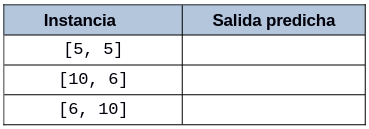

*   Pregunta guía: ¿Las predicciones obtenidas son coherentes con la ubicación visual de los puntos respecto a la frontera de decisión?

        Sí, las predicciones son coherentes con la ubicación visual de los puntos respecto a la frontera aprendida.



**Actividad 6.b — Dataset extendido**

Agrega las nuevas instancias a una copia del dataset original. Agrega también sus salidas predichas al vector de etiquetas.

Luego grafica nuevamente el dataset extendido con la frontera aprendida.

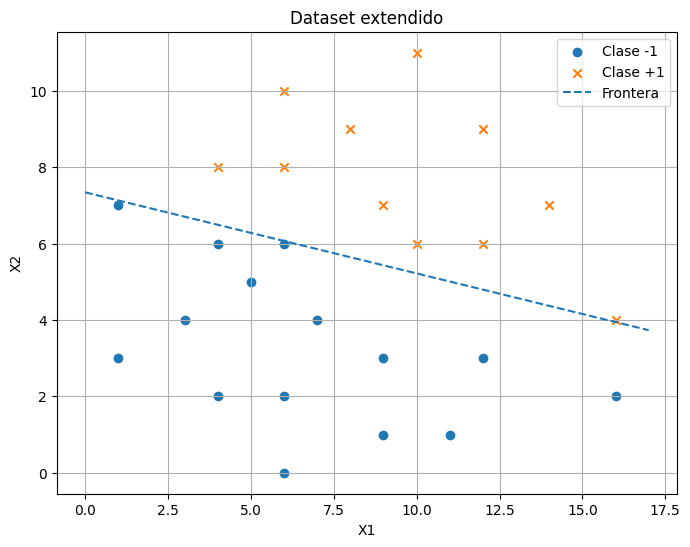

In [21]:
import numpy as np

X_extended = X.copy()
y_extended = y.copy()

# Agregar nuevas instancias
for instancia in X_test:

    pred = perceptron_compute(
        instancia,
        final_w
    )

    # Agregar fila a X
    X_extended = np.vstack([
        X_extended,
        instancia
    ])

    # Agregar etiqueta a y
    y_extended = np.append(
        y_extended,
        pred
    )
perceptron_plot(
    X_extended,
    y_extended,
    final_w,
    "Dataset extendido"
)

*   Pregunta guía: ¿Las nuevas instancias quedaron ubicadas en la región esperada del plano? ¿Alguna predicción parece discutible? Justifica tu respuesta.

        - Las nuevas instancias quedaron ubicadas en regiones coherentes del plano según la frontera aprendida.
        - Algunas predicciones cercanas a la recta podrían considerarse discutibles debido a la proximidad entre clases.



#**Fase 7. Evolución de la Frontera de Decisión**

El entrenamiento del perceptrón modifica gradualmente los pesos. Como los pesos determinan la frontera de decisión, es posible observar cómo cambia la recta durante el aprendizaje.

**7.1 Actividades de visualización del entrenamiento**



**Actividad 7.a — Seis estados del entrenamiento**

Crea seis gráficas diferentes que muestren la evolución de la frontera de decisión. Selecciona los siguientes momentos:

    • Estado inicial
    • 20% del entrenamiento
    • 40% del entrenamiento
    • 60% del entrenamiento
    • 80% del entrenamiento
    • Estado final

Si el entrenamiento tuvo menos de seis épocas, grafica todos los estados disponibles.

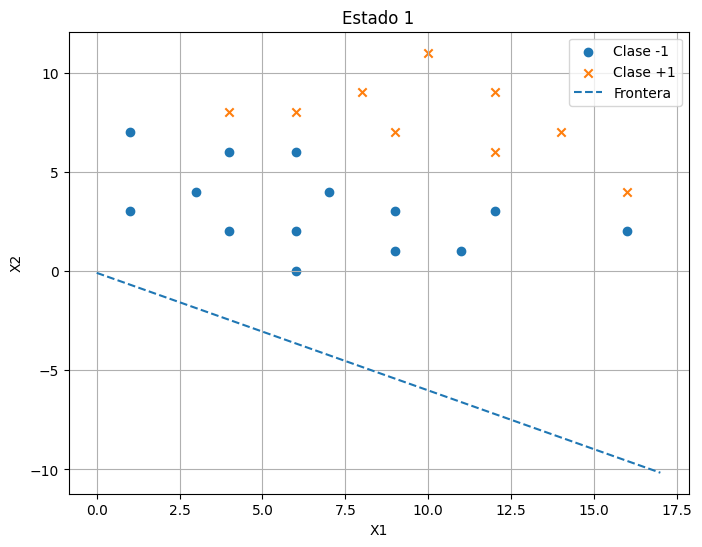

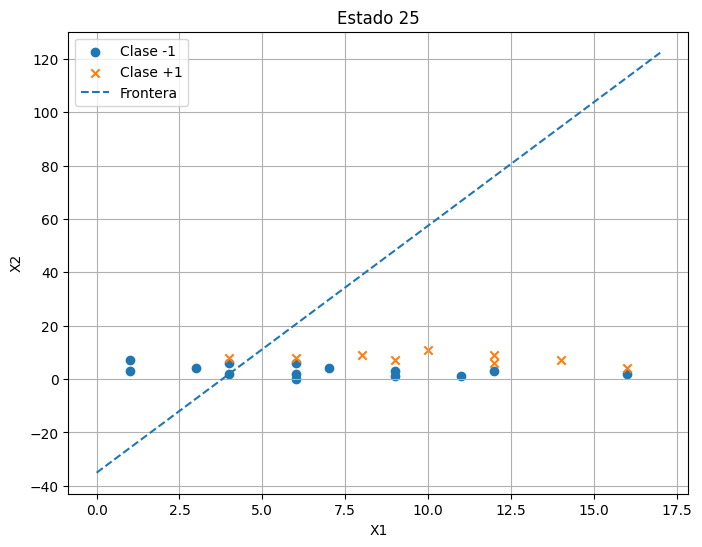

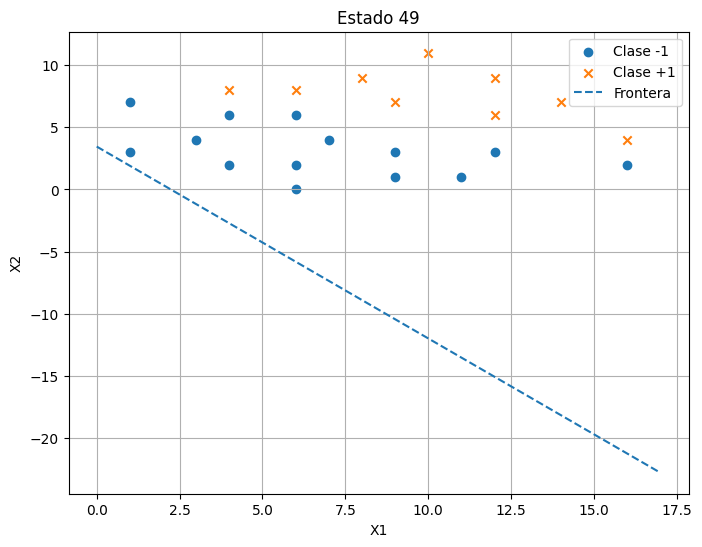

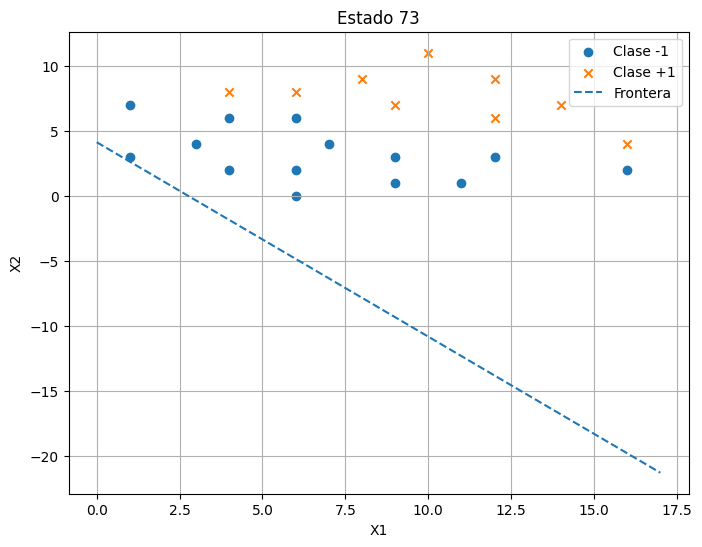

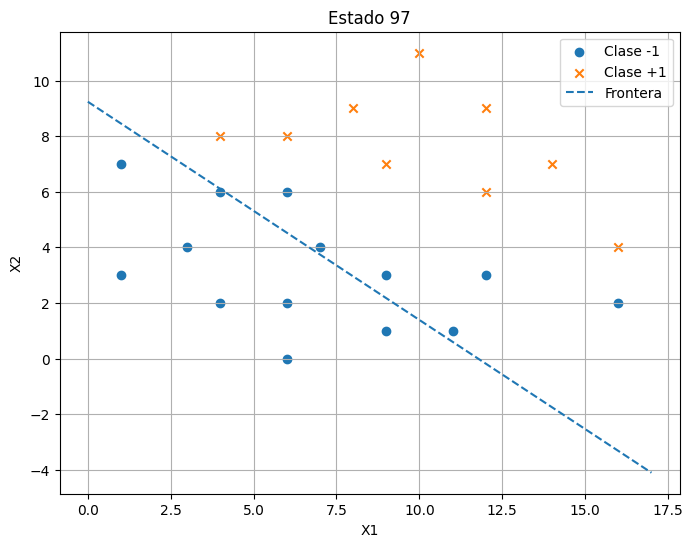

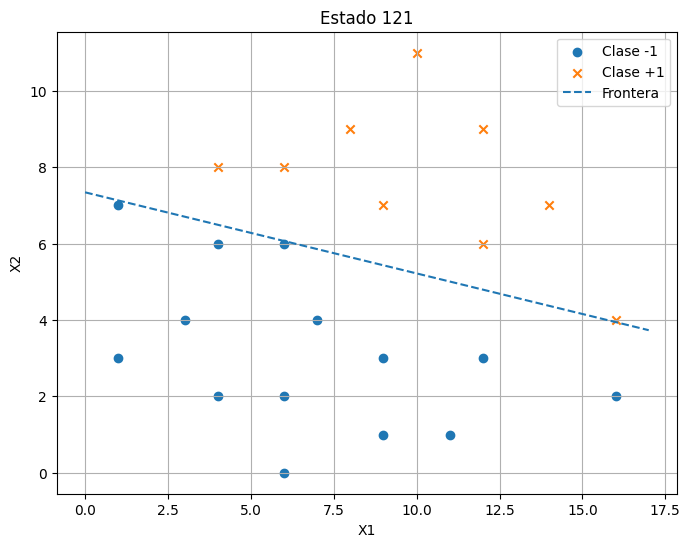

In [22]:
total = len(W_values)

indices = [
    0,
    int(total * 0.2),
    int(total * 0.4),
    int(total * 0.6),
    int(total * 0.8),
    total - 1
]
for i in indices:
    perceptron_plot(
        X,
        y,
        W_values[i],
        f"Estado {i+1}"
    )

*   Pregunta guía: ¿Qué ocurre con la frontera de decisión a medida que se actualizan los pesos? ¿El cambio parece estable o brusco?

        - La frontera de decisión cambia gradualmente conforme los pesos son actualizados.
        - Los movimientos pueden ser bruscos al inicio y más estables cerca de la convergencia.


**Actividad 7.b — Interpretación geométrica**

Analiza cómo se desplaza o rota la recta durante el entrenamiento.


*   ¿Qué peso parece influir más en la inclinación de la recta? ¿Qué papel parece cumplir el bias en el desplazamiento de la frontera?


        - Los pesos asociados a x1 y x2 influyen principalmente en la inclinación de la recta.
        - El bias desplaza la frontera horizontal o verticalmente en el plano.

#**Fase 8. Evolución del Error**

Además de observar la frontera de decisión, es necesario analizar cómo cambia el error durante el entrenamiento.

**8.1 Actividades sobre el error**

**Actividad 8.a — Gráfica de error**

Crea una función llamada plot_error(E_values, title) La función debe graficar:

    • Eje X: época
    • Eje Y: tasa de error
    • Título
    • Cuadrícula

Luego grafica la evolución del error para el entrenamiento con lr = 0.5.

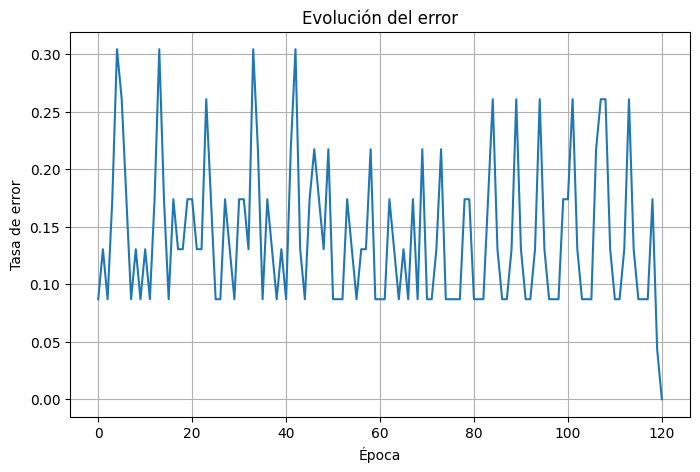

In [23]:
def plot_error(E_values, title):

    plt.figure(figsize=(8,5))
    plt.plot(E_values)
    plt.xlabel("Época")
    plt.ylabel("Tasa de error")
    plt.title(title)
    plt.grid(True)
    plt.show()
plot_error(
    E_values,
    "Evolución del error"
)

*   Pregunta guía: ¿El error disminuye de forma continua en todas las épocas? Si no ocurre así, ¿por qué puede aumentar o mantenerse igual durante algunos momentos del entrenamiento?

        - El error no necesariamente disminuye de manera continua porque durante algunas épocas los cambios de pesos pueden
          generar nuevas clasificaciones incorrectas antes de estabilizarse.



**Actividad 8.b — Análisis de convergencia**



Observa la última época del entrenamiento.
*   Pregunta guía: ¿Qué significa que el error final sea igual a cero? ¿Significa que el modelo es perfecto para cualquier dato futuro? Justifica tu respuesta.


        - Un error final igual a cero significa que el perceptrón clasificó correctamente todos los datos de entrenamiento.
        - Sin embargo, esto no garantiza un desempeño perfecto con datos futuros no vistos.




#**Fase 9. Comparación de Tasas de Aprendizaje**

La tasa de aprendizaje controla la magnitud de los cambios aplicados a los pesos cuando el perceptrón comete un error. En esta fase repetirás el entrenamiento con:

    • lr = 0.3
    • lr = 0.5
    • lr = 0.8
    
Para que la comparación sea justa, debes usar los mismos pesos iniciales en los tres experimentos.

**9.1 Actividades de comparación**

**Actividad 9.a — Entrenamiento comparativo**

Inicializa un único vector de pesos iniciales y crea copias para cada valor de lr. Para cada tasa de aprendizaje, registra:

    • Pesos finales
    • Número de épocas
    • Número total de actualizaciones
    • Error final

Convergencia alcanzada.

Learning Rate: 0.3
Pesos finales: [np.float64(-15.034096787714237), np.float64(0.4373770396518815), np.float64(2.039324707406496)]
Épocas: 94
Actualizaciones: 279
Error final: 0.0


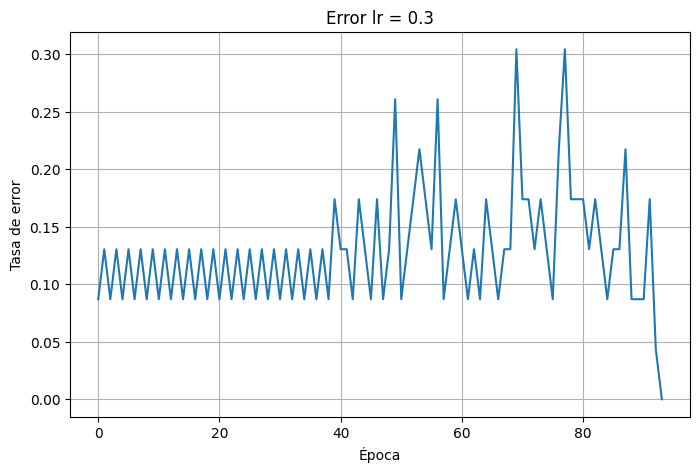

Convergencia alcanzada.

Learning Rate: 0.5
Pesos finales: [np.float64(-67.83409678771423), np.float64(2.9373770396518797), np.float64(7.939324707406509)]
Épocas: 276
Actualizaciones: 917
Error final: 0.0


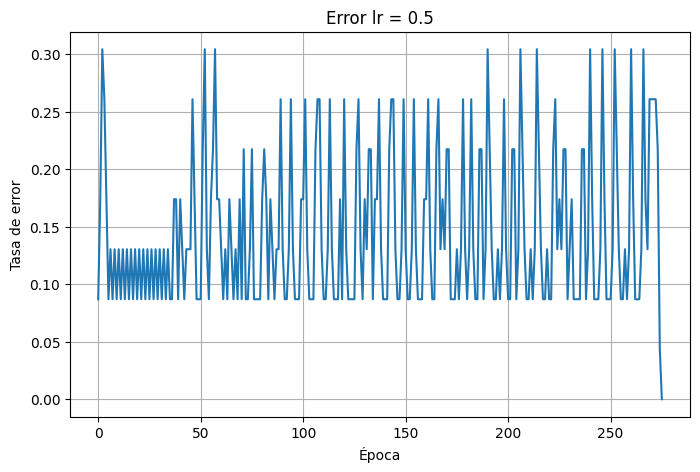

Convergencia alcanzada.

Learning Rate: 0.8
Pesos finales: [np.float64(-99.534096787714), np.float64(4.437377039651824), np.float64(11.939324707406385)]
Épocas: 218
Actualizaciones: 796
Error final: 0.0


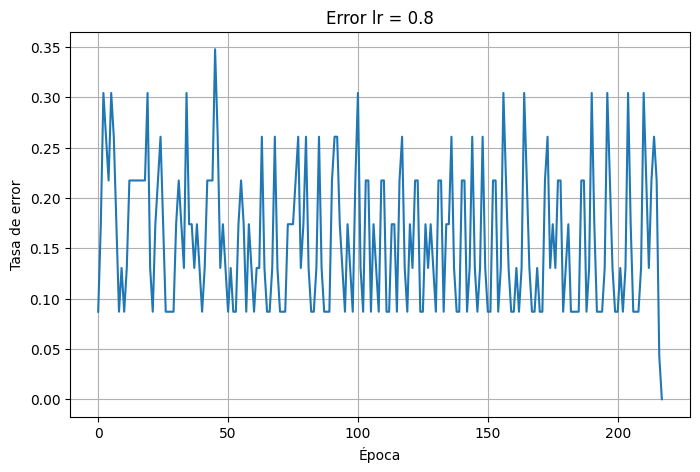

In [24]:
learning_rates = [0.3, 0.5, 0.8]

w_base = initialize_weights()

resultados = []

for lr in learning_rates:

    w_copy = w_base.copy()
    final_w, epochs, updates, W_values, E_values = perceptron_learning(
        X,
        y,
        w_copy,
        lr,
        1000
    )
    resultados.append([
        lr,
        epochs,
        updates,
        E_values[-1],
        final_w
    ])
    print("\n================================")
    print("Learning Rate:", lr)

    print("Pesos finales:", final_w)
    print("Épocas:", epochs)
    print("Actualizaciones:", updates)
    print("Error final:", E_values[-1])

    plot_error(
        E_values,
        f"Error lr = {lr}"
    )

*   Pregunta guía: ¿Por qué no sería justo comparar las tasas de aprendizaje usando pesos iniciales diferentes?

        - No sería justo usar pesos iniciales distintos porque las diferencias observadas podrían deberse
          a los pesos iniciales y no a la tasa de aprendizaje.



**Actividad 9.b — Gráficas comparativas**

Para cada valor de lr, genera:

        • seis gráficas de evolución de la frontera;
        • gráfica de evolución del error.





*   Pregunta guía: ¿Qué tasa de aprendizaje permitió alcanzar la convergencia con menos épocas? ¿Eso significa necesariamente que es la mejor tasa de aprendizaje?

        - Una tasa de aprendizaje alta puede converger más rápido, pero también puede generar cambios bruscos e inestabilidad.
        - La mejor tasa de aprendizaje no siempre es la que converge en menos épocas.

**Actividad 9.c — Tabla comparativa**

Construye una tabla como la siguiente:

In [34]:
print(
    f"{'lr':<10}"
    f"{'Épocas':<12}"
    f"{'Actualizaciones':<20}"
    f"{'Error final':<18}"
    f"{'Pesos Finales'}"
)
print("-" * 70)

for r in resultados:
    print(
        f"{r[0]:<10}"
        f"{r[1]:<12}"
        f"{r[2]:<20}"
        f"{r[3]:<18}"
        f"{r[4]}"
    )

lr        Épocas      Actualizaciones     Error final       Pesos Finales
----------------------------------------------------------------------
0.3       94          279                 0.0               [np.float64(-15.034096787714237), np.float64(0.4373770396518815), np.float64(2.039324707406496)]
0.5       276         917                 0.0               [np.float64(-67.83409678771423), np.float64(2.9373770396518797), np.float64(7.939324707406509)]
0.8       218         796                 0.0               [np.float64(-99.534096787714), np.float64(4.437377039651824), np.float64(11.939324707406385)]


*   Pregunta guía: ¿Los pesos finales son iguales para todas las tasas de aprendizaje? Si son diferentes, ¿por qué pueden producir igualmente una clasificación correcta?

        - Los pesos finales pueden ser diferentes para cada tasa de aprendizaje.
        - Sin embargo, distintas combinaciones de pesos pueden producir fronteras equivalentes capaces de
          clasificar correctamente los datos.



**RESULTADOS OBTENIDOS:**

1. Se implementó manualmente el perceptrón, incluyendo inicialización de pesos, función de activación bipolar, cálculo de salida y regla de actualización sin utilizar librerías de machine learning.
2. El modelo logró aprender una frontera de decisión lineal capaz de separar las dos clases del dataset, evidenciando la relación entre pesos, bias y recta de clasificación.
3. Se registró y visualizó la evolución del entrenamiento mediante gráficas de frontera de decisión y curvas de error, observando cómo los pesos modifican geométricamente la separación entre clases.
4. Se compararon distintas tasas de aprendizaje (0.3, 0.5 y 0.8), identificando su influencia en el número de épocas, actualizaciones realizadas, estabilidad del entrenamiento y pesos finales obtenidos.

**CONCLUSIONES:**

1. Durante la práctica se implementó manualmente un perceptrón desde cero, permitiendo comprender el funcionamiento interno de un clasificador lineal supervisado. Además, se observó cómo los pesos y el bias determinan geométricamente la frontera de decisión que separa las clases.
2. La comparación entre diferentes tasas de aprendizaje permitió analizar su impacto en la velocidad de convergencia y estabilidad del entrenamiento. También se comprobó que el perceptrón funciona correctamente únicamente cuando los datos son linealmente separables.

**REFERENCIAS:**

    [1] F. Rosenblatt, “The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain,” Psychological Review, vol. 65, no. 6, pp. 386–408, 1958.
    [2] W. S. McCulloch and W. Pitts, “A Logical Calculus of the Ideas Immanent in Nervous Activity,” Bulletin of Mathematical Biophysics, vol. 5, pp. 115–133, 1943.
    [3] H. Ortega Martínez, Machine Learning Workout: with exercises and practicals in MATLAB. Quito: Editorial Abya-Yala / Universidad Politécnica Salesiana, 2019, ISBN 978-9978-10-394-4. [En línea]. Disponible en: https://dspace.ups.edu.ec/handle/123456789/19046